In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
base_path = Path.cwd()
data_dir = base_path.parent/"data"/"02_cleaned_data"/"cleaned_data.csv"
plot_dir = base_path.parent/"docs"/"plots"

source_df = pd.read_csv(data_dir)

In [3]:
death_overs = source_df[
    source_df['over'] >= 16
]

In [37]:
death_batting_stats = death_overs.groupby(['batting_team','batter']).agg(
    {
        'runs_bat':'sum',
        'ball':'count'
    }
).reset_index()

death_batting_stats['strike_rate'] = death_batting_stats['runs_bat'] / death_batting_stats['ball'] *100

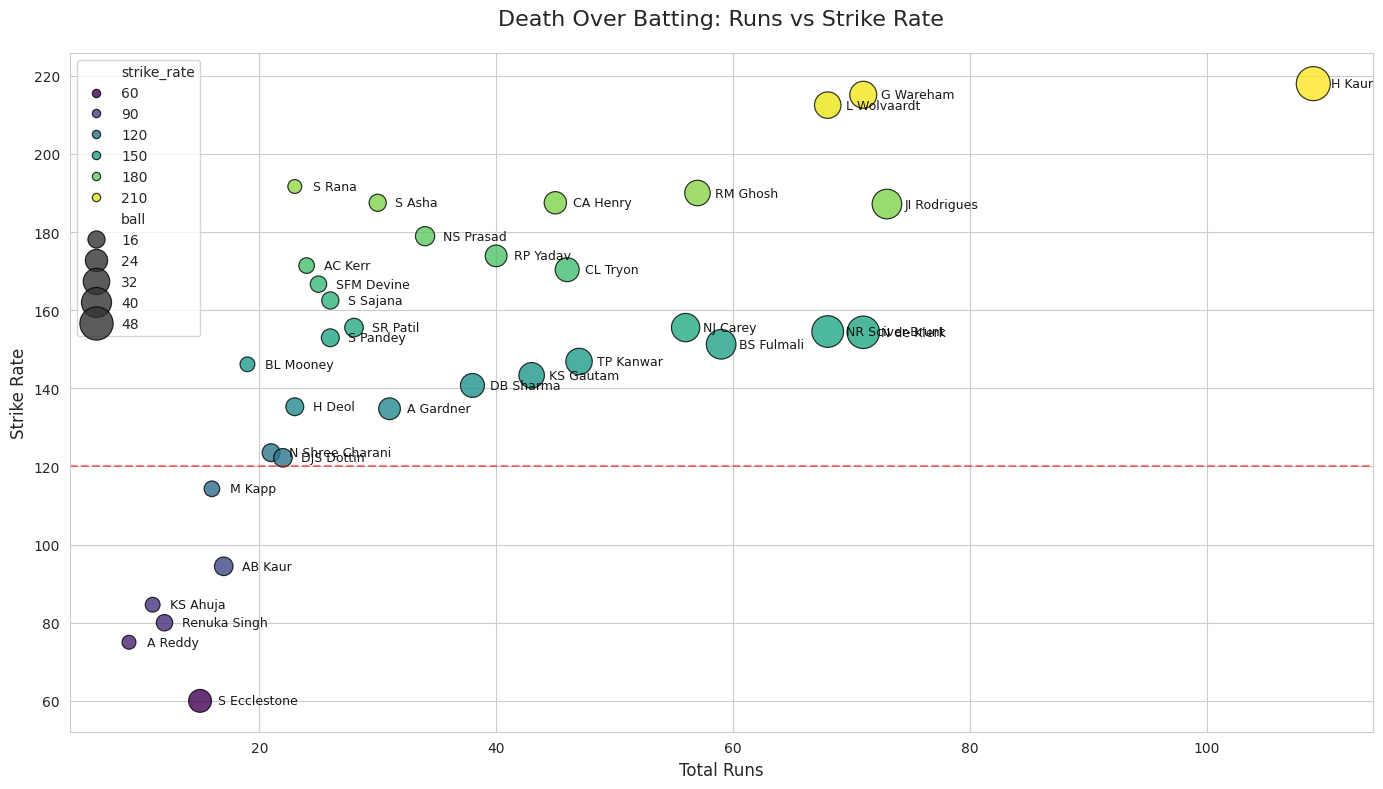

In [17]:
# Visualizing death overs batting
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

top_death_order_batter = death_batting_stats[death_batting_stats['ball'] >= 12]

scatter = sns.scatterplot(
    data=top_death_order_batter,
    x='runs_bat',
    y='strike_rate',
    size='ball',
    hue='strike_rate', 
    palette='viridis',
    sizes=(100, 600),
    edgecolor='black',
    alpha=0.8
)


for i in range(top_death_order_batter.shape[0]):
    plt.text(
        x=top_death_order_batter.iloc[i]['runs_bat']+1.5, 
        y=top_death_order_batter.iloc[i]['strike_rate'], 
        s=top_death_order_batter.iloc[i]['batter'], 
        fontsize=9,
        alpha=0.9,
        ha='left',              
        va='center',            
        color='black'
    )


plt.title('Death Over Batting: Runs vs Strike Rate', fontsize=16, pad=20)
plt.axhline(120, ls='--', color='red', alpha=0.5, label='Avg SR Benchmark')
plt.xlabel('Total Runs', fontsize=12)
plt.ylabel('Strike Rate', fontsize=12)


plt.tight_layout()
plt.savefig(rf'{plot_dir}/death_overs_batting_stats')
plt.show()

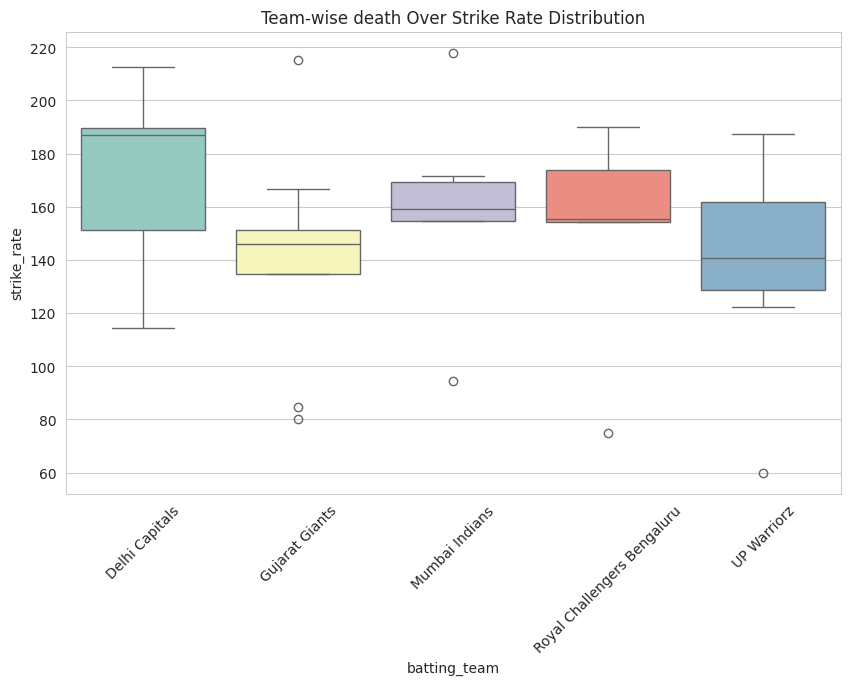

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=top_death_order_batter,
    x='batting_team',
    y='strike_rate',
    hue='batting_team',
    legend=False,
    palette='Set3'
)

plt.xticks(rotation=45)
plt.title('Team-wise death Over Strike Rate Distribution')
plt.savefig(rf'{plot_dir}/death_overs_batting_team_stats.png', bbox_inches='tight')
plt.show()

In [33]:

death_bowling_stats = source_df[source_df['over'] >= 16].copy()


bowler_wicket_types = ['caught', 'stumped', 'bowled', 'lbw', 'caught and bowled', 'hit wicket']
death_bowling_stats['is_bowler_wicket'] = death_bowling_stats['wicket_kind'].fillna(' ').isin(bowler_wicket_types)


death_bowler_stats = death_bowling_stats.groupby(['bowling_team', 'bowler']).agg({
    'runs_bat': 'sum',
    'is_wide': 'sum',
    'is_noball': 'sum',
    'ball': 'count',           
    'is_bowler_wicket': 'sum'  
}).reset_index()


death_bowler_stats.rename(columns={'is_bowler_wicket': 'wickets'}, inplace=True)


death_bowler_stats['total_runs'] = (
    death_bowler_stats['runs_bat'] + 
    death_bowler_stats['is_noball'] + 
    death_bowler_stats['is_wide']
)

death_bowler_stats['legal_balls'] = (
    death_bowler_stats['ball'] - 
    death_bowler_stats['is_wide'] - 
    death_bowler_stats['is_noball']
)

death_bowler_stats['economy'] = np.where(
    death_bowler_stats['legal_balls'] > 0,
    (death_bowler_stats['total_runs'] / death_bowler_stats['legal_balls']) * 6,
    0
)


death_bowler_stats['bowling_sr'] = np.where(
    death_bowler_stats['wickets'] > 0,
    death_bowler_stats['legal_balls'] / death_bowler_stats['wickets'],
    np.nan 
)

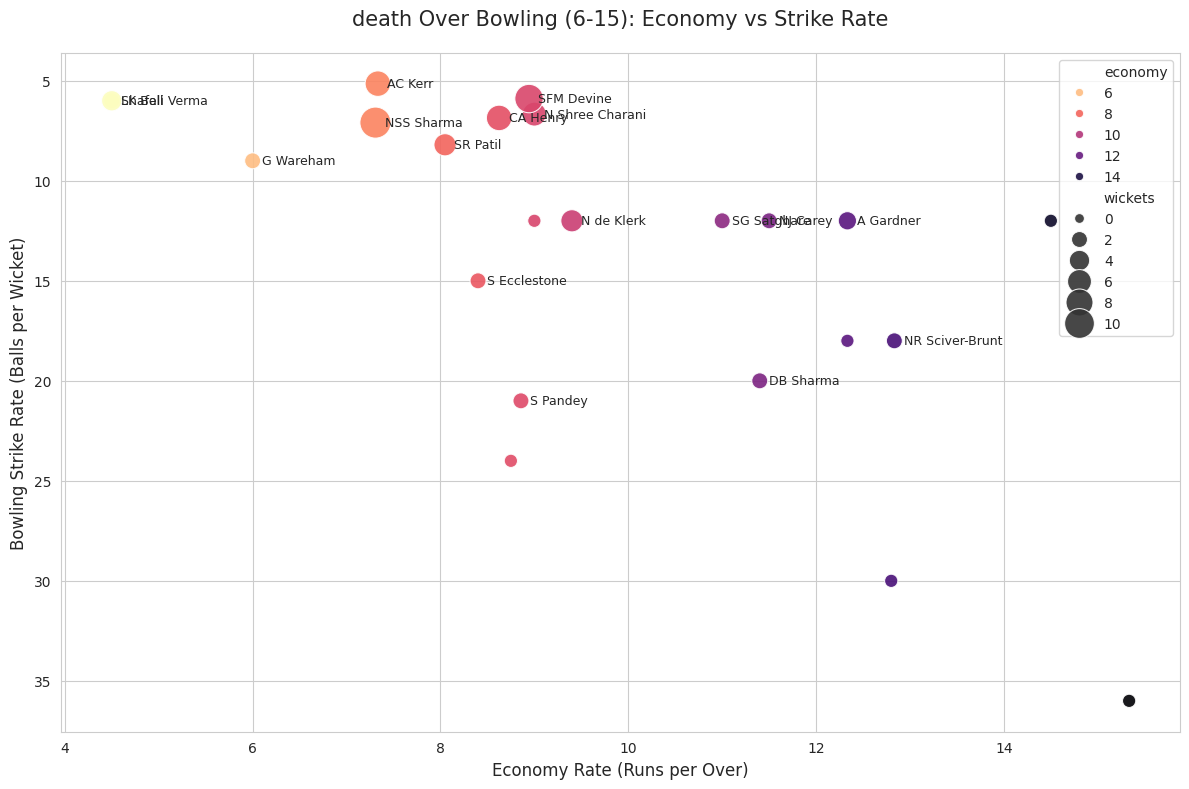

In [34]:
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

top_death_bowlers = death_bowler_stats[death_bowler_stats['ball'] >= 12].copy()

scatter = sns.scatterplot(
    data=top_death_bowlers,
    x='economy',
    y='bowling_sr',
    size='wickets',
    hue='economy',
    palette='magma_r',     
    sizes=(50, 500),
    alpha=0.9
)


for index, row in top_death_bowlers.iterrows():
    if row['economy'] < 7.0 or row['wickets'] >= 2:
        plt.text(
            x=row['economy'] + 0.1, 
            y=row['bowling_sr'], 
            s=row['bowler'], 
            fontsize=9,
            va='center'
        )


plt.title('death Over Bowling (6-15): Economy vs Strike Rate', fontsize=15, pad=20)
plt.xlabel('Economy Rate (Runs per Over)', fontsize=12)
plt.ylabel('Bowling Strike Rate (Balls per Wicket)', fontsize=12)

plt.gca().invert_yaxis() 
plt.tight_layout()
plt.savefig(rf'{plot_dir}/death_overs_bowling_stats')
plt.show()

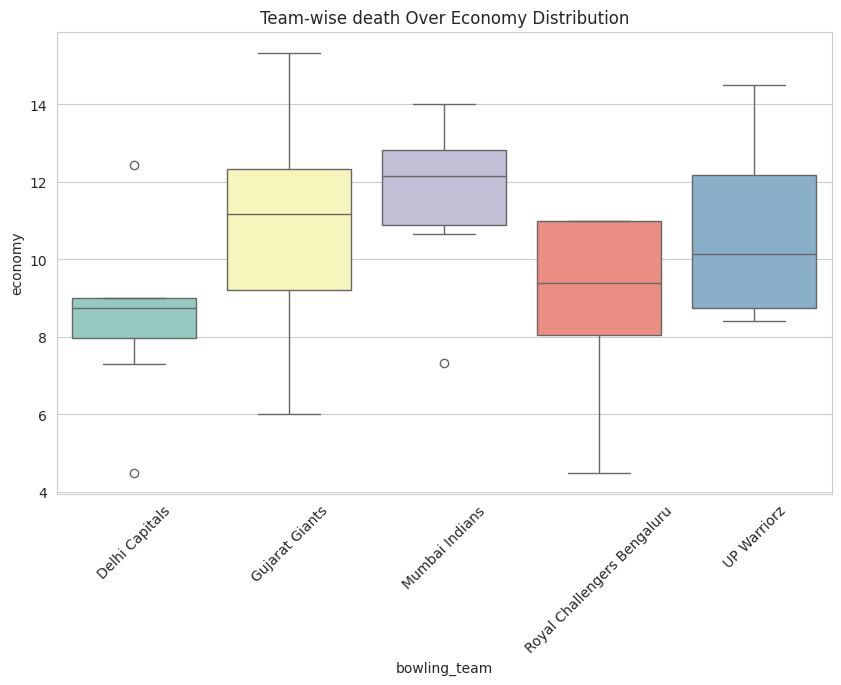

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=top_death_bowlers,
    x='bowling_team',
    y='economy',
    hue='bowling_team',
    legend=False,
    palette='Set3'
)

plt.xticks(rotation=45)
plt.title('Team-wise death Over Economy Distribution')
plt.savefig(rf'{plot_dir}/death_overs_bowling_team_stats',bbox_inches='tight')
plt.show()